# State-figures playground

Interactive notebook to iterate on publication plots for the **state-encoding** family of results:

1. Two example EC cells — one *sustained* state cell (all phases positive), one *not-consistent* (positive in some phases, weak/negative in others). Source: `scripts/encoding_state_sustained_cv.py`.
2. Per-ROI cell count vs fraction sustained, in the `pub_sig_counts_bars.pdf` style.
3. Per-ROI **across-phase** state β heatmap, in the `combined_publication_figure.pdf` style. Source: addon `phase_mask_replay.csv` from `RSA_addon_analyses.py`.
4. Brain-projected across-phase state β — nilearn glass-brain fallback (quickbrain needs Python≥3.10; this env is 3.8.15).

All plot helpers are defined as functions so you can re-run any cell repeatedly with tweaked parameters.

**Inputs** are listed in the path-config cell at the top — swap to new run dirs there.

## 0. Setup

In [1]:
%matplotlib inline
import sys, os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats

REPO = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/multiple_clocks_repo')
sys.path.insert(0, str(REPO))

import era_brewer
import mc.analyse.helpers_human_cells as hh
from mc.plotting.cell_results import (
    plot_significance_counts_bars, CANONICAL_ROI_ORDER,
)

# Showgirl2 colour palette — CLAUDE.md default
PALETTE = era_brewer.era_brew('Showgirl2', n=7)
PHASE_COLORS = [PALETTE[0], PALETTE[1], PALETTE[2]]
PHASES = ['early', 'middle', 'late']
STATES = ['A', 'B', 'C', 'D']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
print('OK')

OK


## 1. Paths — edit these for new runs

In [2]:
DATA = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives')

# Sustained-state CV results — v5 pipeline (OLS, sum-coded phase, min_phase_contrast gate).
# Run tag matches scripts/encoding_state_sustained_cv.py default RELOAD_OLD_RESULTS.
SUSTAINED_RUN = DATA / 'group/encoding_state_sustained_cv/2026-06-25_14-38-13'
FINAL = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/data/final_results/ephys_sustained_state')
PUB_FIGS = SUSTAINED_RUN / 'diagnostic_figures'

# RSA addon phase-mask replay (state β across phase modes per ROI) — fMRI state companion.
RSA_ADDON_CSV = DATA / 'group/DSR_RSA_simple_ROI/2026-06-22_17-49-19/addon/phase_mask_replay.csv'

# ROI MNI table (for brain projection)
ROI_TABLE = DATA / 'neurons_with_final_roi_labels.csv'

# Output dir for the playground figures (local re-exports / scratch)
OUT_DIR = SUSTAINED_RUN / 'playground_figures'
OUT_DIR.mkdir(exist_ok=True)

ROI_ORDER = ['ACC', 'medialOFC', 'PCC', 'Parahippocampal',
             'HC_anterior', 'HC_mid', 'EC']
ROI_LABEL = {'HC_anterior':'HC ant', 'HC_mid':'HC mid', 'medialOFC':'mOFC',
             'Parahippocampal':'PHC', 'medial_CC':'mCC'}
def pretty(r):
    return ROI_LABEL.get(r, r)

print(f'Sustained run: {SUSTAINED_RUN.name}')
print(f'Pub figures:   {PUB_FIGS}')
print(f'Final results: {FINAL}')

Sustained run: 2026-06-22_17-35-48
RSA addon CSV: /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/DSR_RSA_simple_ROI/2026-06-22_17-49-19/addon/phase_mask_replay.csv
Output dir:    /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures


## 2. Load data

In [3]:
# Per-cell sustained-state CV results
sustained = pd.read_csv(SUSTAINED_RUN / 'state_sustained_cv_results.csv')
print(f'sustained: {len(sustained)} cells across {sustained.roi.nunique()} ROIs')

# Parse phase contrasts JSON → array of length 3
def _parse_pc(j):
    if pd.isna(j): return None
    try:
        d = json.loads(j)
        return np.array([d.get('early'), d.get('middle'), d.get('late')], dtype=float)
    except Exception:
        return None
sustained['phase_contrasts'] = sustained['phase_contrast_json'].apply(_parse_pc)
sustained['has_all_positive'] = sustained['phase_contrasts'].apply(
    lambda c: c is not None and np.all(np.isfinite(c)) and np.all(c > 0))

# ROI summary
roi_summary = pd.read_csv(SUSTAINED_RUN / 'state_sustained_cv_roi_summary.csv')
print('\nROI summary:')
print(roi_summary[['roi','n_cells','n_sustained_sig','frac_sustained_sig','binom_p_sustained_sig']].to_string(index=False))

# RSA addon phase-mask replay
addon = pd.read_csv(RSA_ADDON_CSV)
print(f'\naddon phase_mask_replay: {len(addon)} rows, '
      f'{addon.roi.nunique()} ROIs, modes={sorted(addon["mode"].unique())}')

sustained: 955 cells across 7 ROIs

ROI summary:
            roi  n_cells  n_sustained_sig  frac_sustained_sig  binom_p_sustained_sig
            ACC      159               22            0.138365               0.000016
      medialOFC      167               21            0.125749               0.000101
            PCC       64                6            0.093750               0.100097
Parahippocampal       61                4            0.065574               0.364211
    HC_anterior      296               22            0.074324               0.043070
         HC_mid      180               18            0.100000               0.004217
             EC       28                4            0.142857               0.049074

addon phase_mask_replay: 1512 rows, 7 ROIs, modes=['across_phase', 'full', 'within_phase']


## 3. PLOT A — Two example state cells (good EC + bad non-EC)

Uses `mc.plotting.cell_results.plot_single_state_cell_polar` — the same polar layout used in `publication_figures_human_cells.py` fig2 panel C. One subplot per task config (smoothed firing rate as a polar clock around the trial), plus a 'mean across configs' panel. Sustained stats (`mean_r`, `min_phase_contrast` and their p-values) are passed via the function's `enc_*` / `cv_*` slots; the wrapper below overrides the suptitle labels to reflect sustained semantics.

- **Good example**: best sustained EC cell (highest `mean_r` among `sustained_sig=True`).
- **Bad example**: a NOT-sustained cell from another ROI with a strongly negative `min_phase_contrast` (i.e. encoding collapses in at least one phase).

In [4]:
# ── Helpers: load one cell's traces, pick examples, polar-plot via mc.cell_results ──
from mc.plotting.cell_results import plot_single_state_cell_polar

def load_cell_traces(neuron_id):
    """Load behavioural + neuron trace + config labels for a single cell."""
    import re
    m = re.match(r'^(\d+)_', str(neuron_id))
    if not m: return None
    sub_str = m.group(1).zfill(2)
    try:
        data = hh.load_norm_data(str(DATA), [sub_str], res_data=False)
    except Exception as exc:
        print(f'  load failed: {exc}')
        return None
    sd = data.get(f'sub-{sub_str}')
    if sd is None or neuron_id not in sd['normalised_neurons']:
        return None
    beh = sd['beh'].copy().reset_index(drop=True)
    beh['config_str'] = (beh['loc_A'].astype(int).astype(str) + '-' +
                          beh['loc_B'].astype(int).astype(str) + '-' +
                          beh['loc_C'].astype(int).astype(str) + '-' +
                          beh['loc_D'].astype(int).astype(str))
    trace = sd['normalised_neurons'][neuron_id].reset_index(drop=True)
    correct = (beh['correct'] == 1).to_numpy()
    if not correct.any():
        return None
    mean_trace = np.nanmean(trace.iloc[correct].to_numpy(dtype=float), axis=0)
    configs = sorted(beh.loc[correct, 'config_str'].dropna().unique().tolist())
    per_cfg = []
    for cfg in configs:
        idx = beh.index[(beh['config_str']==cfg) & (beh['correct']==1)].to_numpy()
        per_cfg.append(np.nanmean(trace.iloc[idx].to_numpy(dtype=float), axis=0)
                       if len(idx) else None)
    return {'neuron_id': neuron_id, 'mean_trace': mean_trace,
            'per_cfg': per_cfg, 'configs': configs}

def plot_sustained_cell_polar(cell_row, cell_data, save_path=None,
                              kind_label='good', smooth_sigma=4, n_cols=3):
    """Wrapper around `plot_single_state_cell_polar` that maps sustained
    stats into its slots, then overrides the suptitle with sustained labels.

    Mapping:
      cv_consistency  <- min_phase_contrast      (worst-phase preferred-state contrast)
      cv_p_perm       <- p_perm_min_phase_contrast
      enc_state_mean_r<- mean_r                  (CV state-encoding r)
      enc_p_perm      <- p_perm_state_r
    """
    # Call the canonical helper to do the layout + render + save.
    plot_single_state_cell_polar(
        mean_trace=cell_data['mean_trace'],
        traces_per_config=cell_data['per_cfg'],
        configs=cell_data['configs'],
        cell_label=cell_row['neuron'],
        roi=cell_row['roi'],
        cv_consistency=float(cell_row['min_phase_contrast']),
        enc_state_mean_r=float(cell_row['mean_r']),
        cv_p_perm=float(cell_row['p_perm_min_phase_contrast']),
        enc_p_perm=float(cell_row['p_perm_state_r']),
        save_path=str(save_path) + '.png' if save_path else None,
        smooth_sigma=smooth_sigma,
        n_cols=n_cols,
    )
    # Reopen the saved file so we can rewrite the suptitle with sustained
    # labels instead of CV/encoding labels. Simpler: re-render entirely with
    # the same helper, capture the fig before plt.close, and over-write the
    # suptitle. The helper closes its fig — so we re-call privately with the
    # internal pieces.
    from mc.plotting.cell_results import smooth_circular, plot_state_polar_clock
    smoothed_mean = smooth_circular(cell_data['mean_trace'], sigma=smooth_sigma)
    smoothed_per = [smooth_circular(t, sigma=smooth_sigma)
                    if (t is not None and np.isfinite(t).any()) else None
                    for t in cell_data['per_cfg']]
    finite = [smoothed_mean] + [t for t in smoothed_per if t is not None]
    rmin = float(np.nanmin([np.nanmin(t) for t in finite])) if finite else 0.0
    rmax = float(np.nanmax([np.nanmax(t) for t in finite])) if finite else 1.0
    rlim = (rmin, rmax)
    n_panels = 1 + len(cell_data['configs'])
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.8 * n_cols, 4.8 * n_rows),
                             subplot_kw=dict(projection='polar'), squeeze=False)
    plot_state_polar_clock(smoothed_mean, title_string='mean across configs',
                            ax=axes[0,0], rlim=rlim,
                            fontsize_labels=18, fontsize_title=11, title_pad=18)
    for i, (cfg, t) in enumerate(zip(cell_data['configs'], smoothed_per)):
        idx = i + 1
        ax = axes[idx // n_cols, idx % n_cols]
        if t is None:
            ax.set_axis_off(); continue
        plot_state_polar_clock(t, title_string=f'cfg {cfg}', ax=ax, rlim=rlim,
                                fontsize_labels=16, fontsize_title=9, title_pad=14)
    for k in range(n_panels, n_rows * n_cols):
        axes[k // n_cols, k % n_cols].axis('off')
    title = (
        f"{kind_label.upper()} — {cell_row['neuron']}  [{cell_row['roi']}]\n"
        f"state-encoding mean r = {cell_row['mean_r']:+.3f}  "
        f"(p_perm = {cell_row['p_perm_state_r']:.3g}, "
        f"q_FDR = {cell_row['q_state_r_within_roi']:.3g})\n"
        f"min-phase pref-state contrast = {cell_row['min_phase_contrast']:+.3f}  "
        f"(p_perm = {cell_row['p_perm_min_phase_contrast']:.3g}, "
        f"q_FDR = {cell_row['q_min_phase_contrast_within_roi']:.3g})  |  "
        f"sustained_sig = {cell_row['sustained_sig']}"
    )
    fig.suptitle(title, fontsize=11, y=0.995)
    fig.subplots_adjust(left=0.05, right=0.97, top=0.88, bottom=0.04,
                        wspace=0.35, hspace=0.45)
    if save_path is not None:
        fig.savefig(str(save_path) + '.pdf', bbox_inches='tight')
        fig.savefig(str(save_path) + '.png', dpi=200, bbox_inches='tight')
        print(f'  saved -> {save_path}.pdf')
    return fig

def find_good_EC_example(sustained_df):
    ec = sustained_df[(sustained_df['roi']=='EC') & (sustained_df['sustained_sig'])]
    return ec.sort_values('mean_r', ascending=False).iloc[0] if len(ec) else None

def find_bad_other_example(sustained_df, exclude_roi='EC'):
    """Cell from any ROI != exclude_roi with sustained_sig=False AND the most
    negative min_phase_contrast (= worst phase collapse) AND positive mean_r
    (so the cell DOES encode state on average, just not consistently)."""
    cand = sustained_df[(sustained_df['roi'] != exclude_roi) &
                        (~sustained_df['sustained_sig']) &
                        (sustained_df['mean_r'] > 0)]
    return cand.sort_values('min_phase_contrast', ascending=True).iloc[0] if len(cand) else None

good = find_good_EC_example(sustained)
bad  = find_bad_other_example(sustained, exclude_roi='EC')
print('Good EC:', good['neuron'] if good is not None else '—',
      f"mean_r={good['mean_r']:+.4f}" if good is not None else '',
      f"min_phase={good['min_phase_contrast']:+.4f}" if good is not None else '')
print('Bad ', bad['roi'] if bad is not None else '?', ':',
      bad['neuron'] if bad is not None else '—',
      f"mean_r={bad['mean_r']:+.4f}" if bad is not None else '',
      f"min_phase={bad['min_phase_contrast']:+.4f}" if bad is not None else '')


Good EC: 01_06-06-chan119-EC mean_r=+0.1730 min_phase=+0.6604
Bad  HC_mid : 09_30-30-mRT2bHb02-HC mean_r=+0.0294 min_phase=-1.4430


loading files for subject 01
  [single-cell polar] saved → /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/A1_example_good_EC.png
  saved -> /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/A1_example_good_EC.pdf


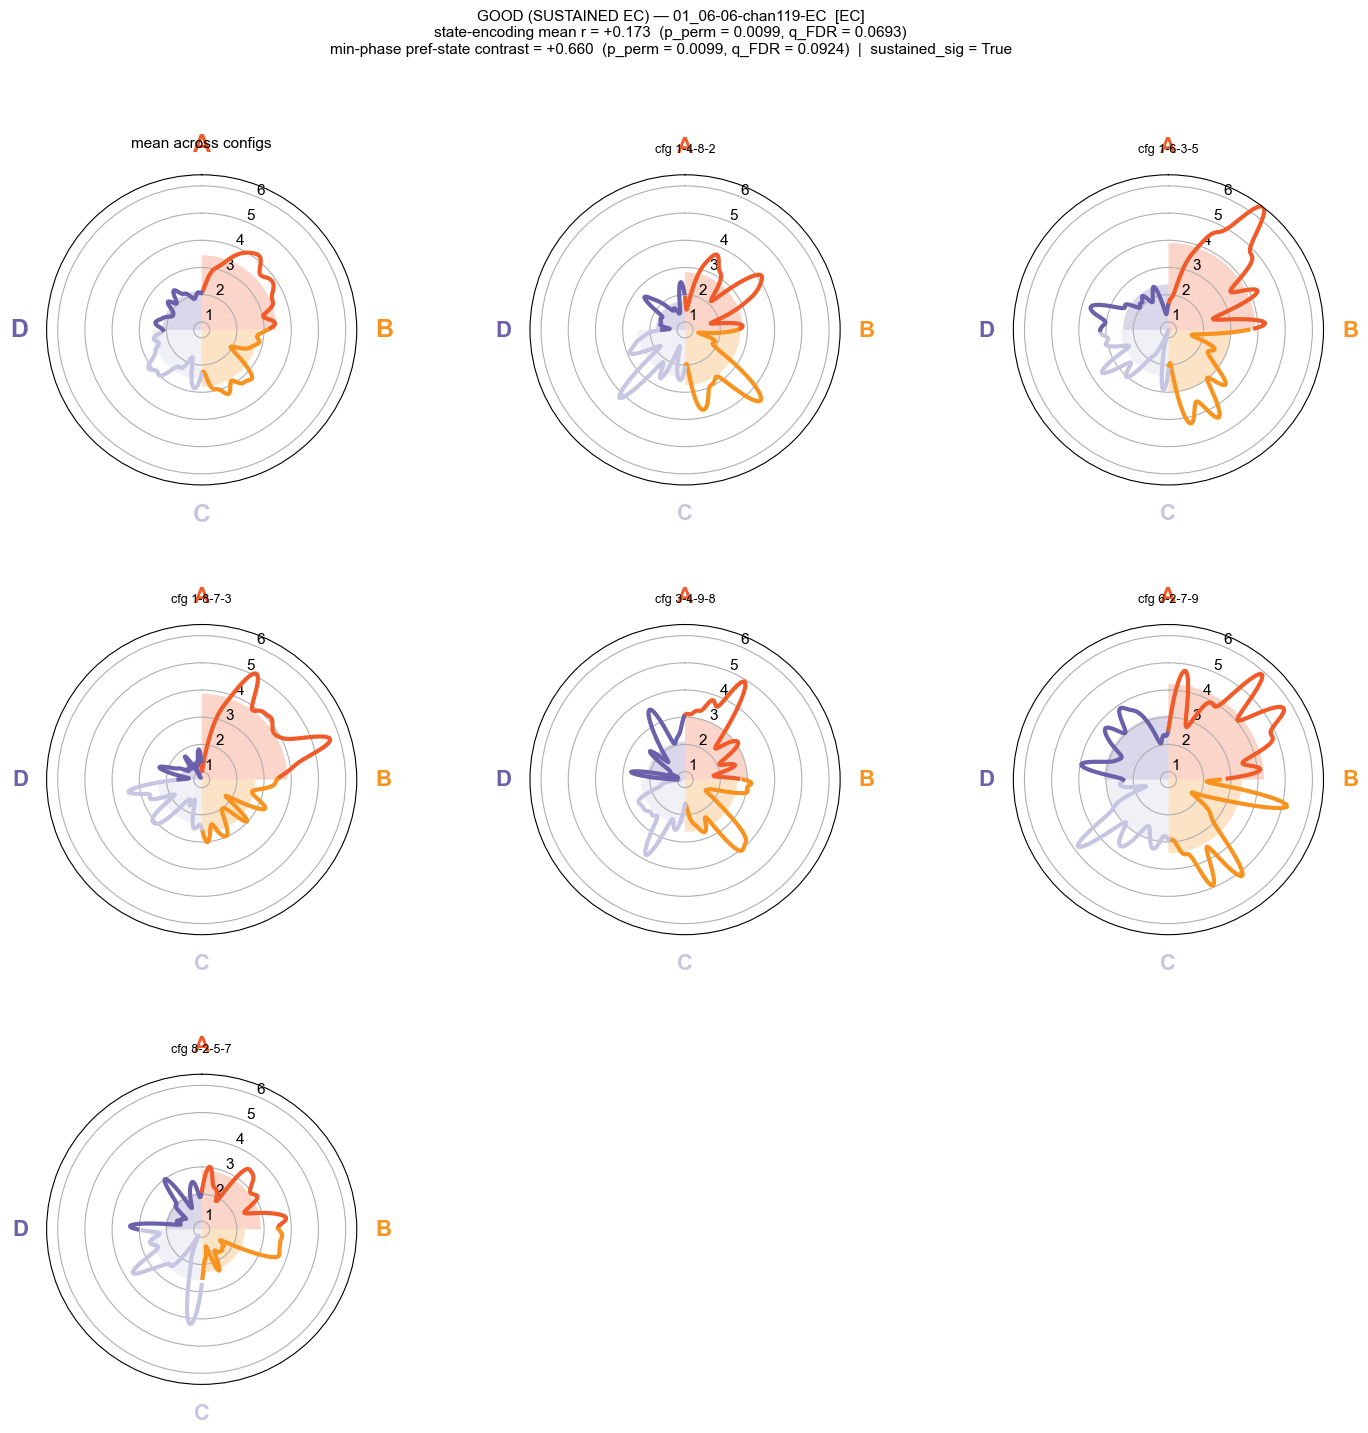

loading files for subject 09
  [single-cell polar] saved → /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/A2_example_bad_HC_mid.png
  saved -> /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/A2_example_bad_HC_mid.pdf


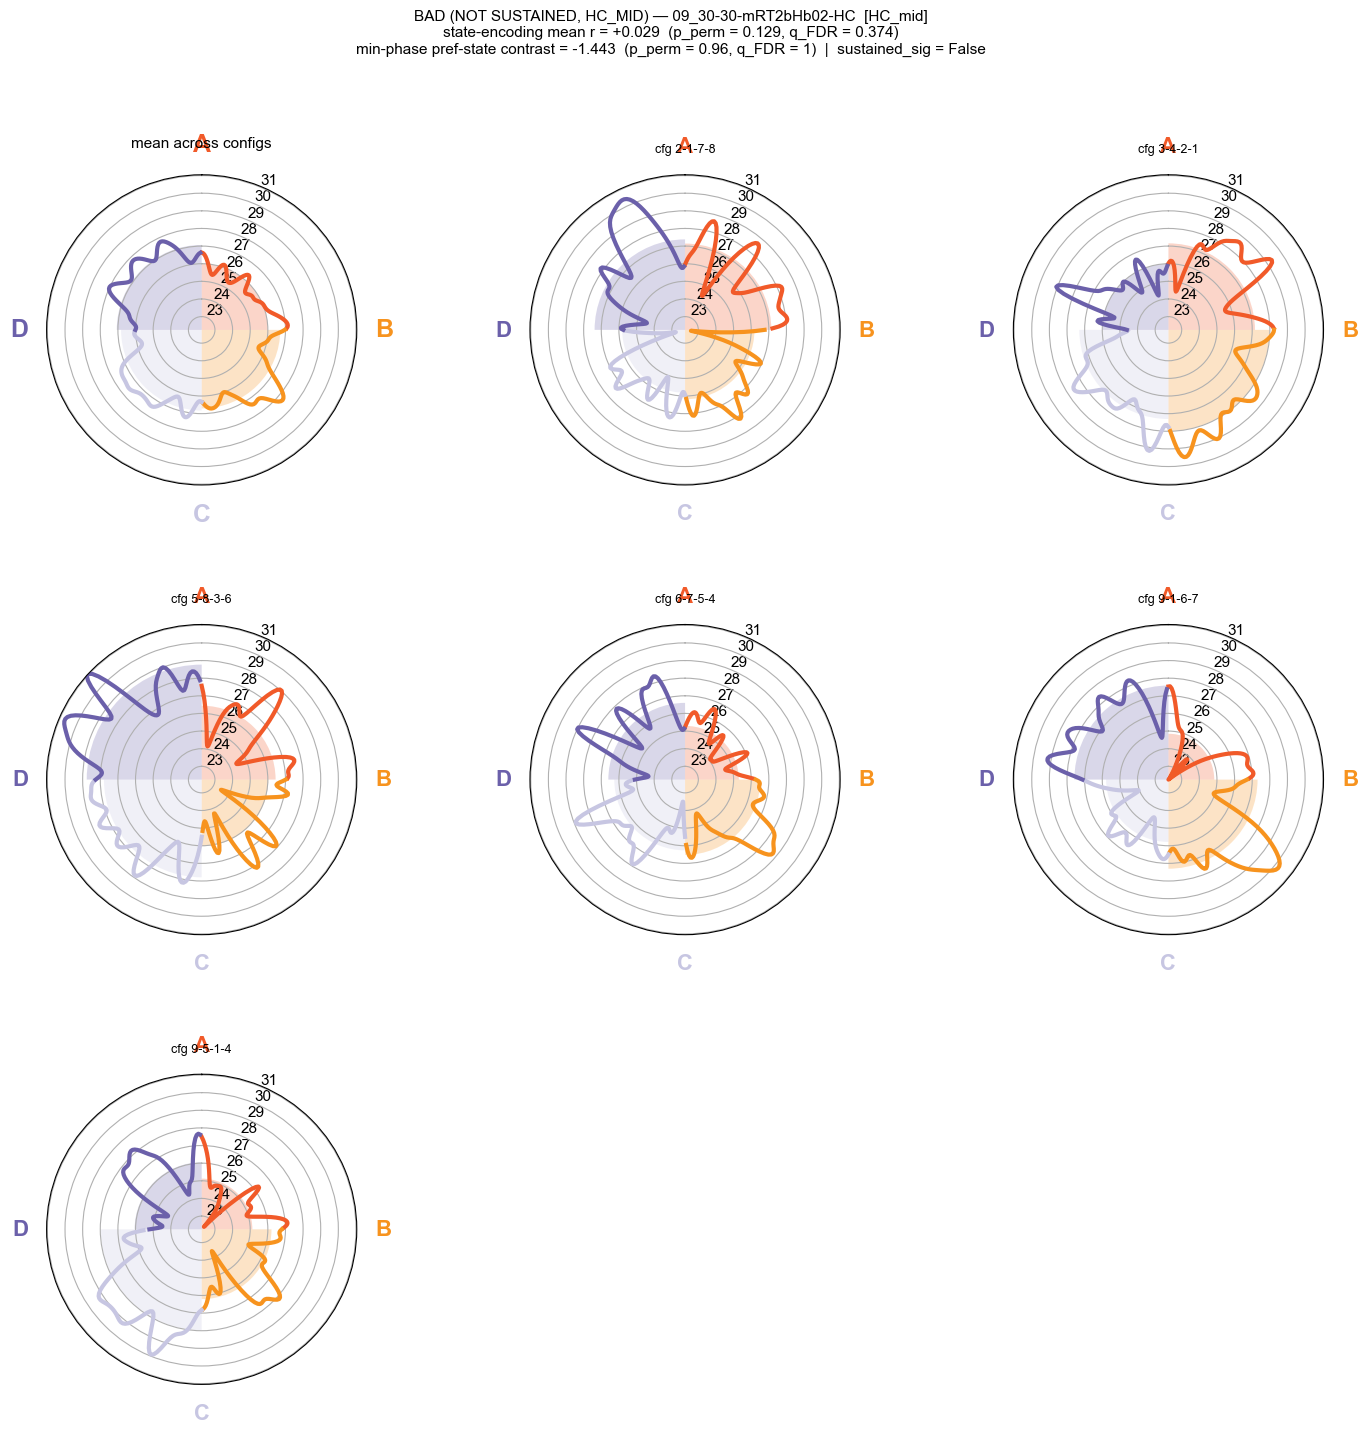

In [5]:
# Render each example (one figure per cell — the mc helper does the layout).
if good is not None:
    d = load_cell_traces(good['neuron'])
    if d:
        plot_sustained_cell_polar(
            good, d, kind_label='GOOD (sustained EC)',
            save_path=OUT_DIR / 'A1_example_good_EC',
        )
        plt.show()

if bad is not None:
    d2 = load_cell_traces(bad['neuron'])
    if d2:
        plot_sustained_cell_polar(
            bad, d2, kind_label=f"BAD (not sustained, {bad['roi']})",
            save_path=OUT_DIR / f'A2_example_bad_{bad["roi"]}',
        )
        plt.show()


## 4. PLOT B — per-ROI sustained-state significance counts

Style mirrors `pub_sig_counts_bars.pdf`: grey background bar = total cells per ROI, coloured foreground bar = number of sustained-sig cells. Stars from BH-FDR-corrected binomial test (chance level = 0.05).

  [sig-counts-bars] saved → /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/B_sustained_sig_counts_per_roi.png (+ .svg, .pdf)


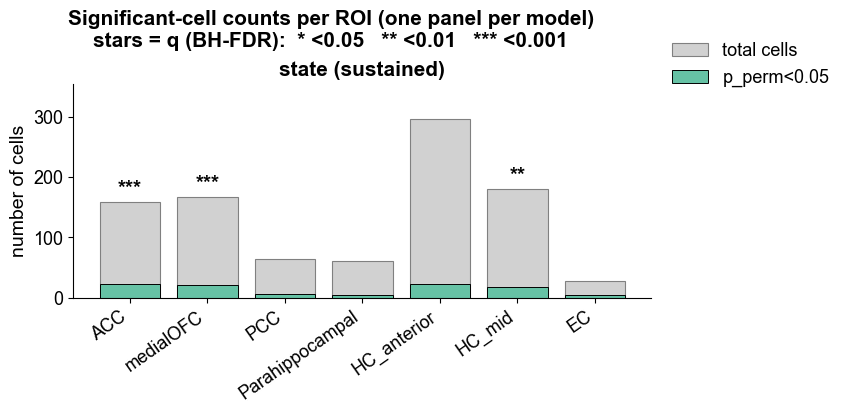

Saved -> /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/B_sustained_sig_counts_per_roi.pdf / .png / .svg


In [6]:
# `plot_significance_counts_bars` expects columns ['roi','model','mean_r','p_perm'].
# Adapt the sustained-cv table: encode sustained_sig as p_perm < alpha.
def sustained_to_results_df(df):
    out = df[['roi','neuron','mean_r','sustained_sig']].copy()
    out['model'] = 'state (sustained)'
    out['p_perm'] = np.where(out['sustained_sig'], 0.0, 1.0)
    return out[['neuron','roi','model','mean_r','p_perm']]

results_df = sustained_to_results_df(sustained)
fig_path = OUT_DIR / 'B_sustained_sig_counts_per_roi'
plot_significance_counts_bars(
    results_df,
    models=['state (sustained)'],
    rois=ROI_ORDER,
    save_path=str(fig_path) + '.png',  # function also writes .pdf + .svg
    alpha=0.05,
    chance_level=0.05,
    use_fdr=True,
    base_fontsize=13,
    panel_w=5.5, panel_h=4.0,
)
plt.show()
print(f'Saved -> {fig_path}.pdf / .png / .svg')

## 5. PLOT C — across-phase state β heatmap (BH-FDR-corrected)

Only the **across_phase** mode (state representations that survive when comparing pairs of conditions in DIFFERENT phases — i.e. truly state-locked, not phase-locked). p-values are BH-FDR-corrected across the 7 ROIs. Source: addon `phase_mask_replay.csv`.

across_phase state β + BH-FDR across ROIs:
                 n_pairs_kept      beta         t       p_param     q_fdr  sig_fdr
roi                                                                               
ACC                      2688  0.099559  5.128394  3.130659e-07  0.000002     True
medialOFC                2688  0.096671  4.986436  6.542676e-07  0.000002     True
PCC                      2688  0.061866  3.178425  1.497639e-03  0.002621     True
Parahippocampal          2688  0.032028  1.648412  9.938534e-02  0.099385    False
HC_anterior              2688  0.038564  1.978247  4.800305e-02  0.056004    False
HC_mid                   2688  0.068722  3.540987  4.054247e-04  0.000946     True
EC                       2688  0.048128  2.471099  1.353157e-02  0.018944     True


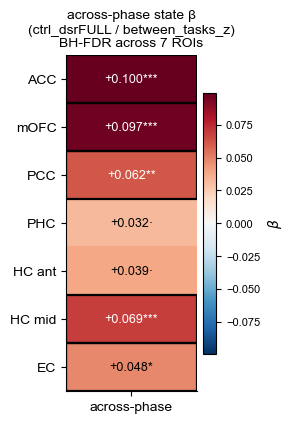

Saved -> /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/C_across_phase_state_heatmap_FDR.pdf


In [7]:
def _bh_fdr(p):
    p = np.asarray(p, dtype=float)
    q = np.full_like(p, np.nan)
    ok = np.isfinite(p)
    if not ok.any(): return q
    pv = p[ok]; n = pv.size
    order = np.argsort(pv)
    ranked = pv[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    qok = np.empty(n); qok[order] = np.clip(ranked, 0, 1)
    q[ok] = qok
    return q

def plot_across_phase_state_heatmap(addon_df, combo='ctrl_dsrFULL',
                                    test='between_tasks_z', sub_model='state',
                                    rois=ROI_ORDER, cmap='RdBu_r',
                                    alpha=0.05, save_stem=None, ax=None,
                                    title=None):
    sub = addon_df[(addon_df['combo']==combo) &
                   (addon_df['test']==test) &
                   (addon_df['sub_model']==sub_model) &
                   (addon_df['mode']=='across_phase')].copy()
    rois = [r for r in rois if r in set(sub['roi'])]
    sub = sub.set_index('roi').reindex(rois)
    sub['q_fdr'] = _bh_fdr(sub['p_param'].to_numpy())
    sub['sig_fdr'] = sub['q_fdr'] < alpha
    print('across_phase state β + BH-FDR across ROIs:')
    print(sub[['n_pairs_kept','beta','t','p_param','q_fdr','sig_fdr']].to_string())

    M = sub['beta'].to_numpy()[:, None]
    Q = sub['q_fdr'].to_numpy()[:, None]
    vmax = float(np.nanmax(np.abs(M))) if np.isfinite(M).any() else 0.2
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.8, 0.45 * len(rois) + 1.0),
                                constrained_layout=True)
    else:
        fig = ax.figure
    im = ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks([0]); ax.set_xticklabels(['across-phase'], fontsize=10)
    ax.set_yticks(range(len(rois)))
    ax.set_yticklabels([pretty(r) for r in rois], fontsize=10)
    for i in range(len(rois)):
        v = float(M[i, 0]); q = float(Q[i, 0])
        if not np.isfinite(v): continue
        star = ('***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05
                else '·' if q<0.10 else '')
        # Black box around FDR-significant cells (mirrors combined_publication_figure)
        if q < alpha:
            ax.add_patch(plt.Rectangle((-0.5, i - 0.5), 1, 1, fill=False,
                                        edgecolor='black', linewidth=1.6))
        ax.text(0, i, f'{v:+.3f}{star}', ha='center', va='center',
                fontsize=9, color='white' if abs(v) > 0.55 * vmax else 'black')
    cb = fig.colorbar(im, ax=ax, fraction=0.10, pad=0.05)
    cb.ax.tick_params(labelsize=8)
    cb.set_label(r'$\beta$', fontsize=10)
    if title is None:
        title = f'across-phase state β\n({combo} / {test})\nBH-FDR across {len(rois)} ROIs'
    ax.set_title(title, fontsize=10)
    for sp in ('top','right'):
        ax.spines[sp].set_visible(False)
    if save_stem:
        fig.savefig(str(save_stem) + '.pdf', bbox_inches='tight')
        fig.savefig(str(save_stem) + '.png', dpi=300, bbox_inches='tight')
    return fig, ax

fig, ax = plot_across_phase_state_heatmap(
    addon, combo='ctrl_dsrFULL', test='between_tasks_z',
    save_stem=OUT_DIR / 'C_across_phase_state_heatmap_FDR',
)
plt.show()
print(f'Saved -> {OUT_DIR}/C_across_phase_state_heatmap_FDR.pdf')


## 6. PLOT D — brain projection (across-phase state β per ROI)

**Notebook note**: [quickbrain](https://pni-lab.github.io/quickbrain/getting-started/) requires Python ≥3.10 and this env (`env_multiple_clocks`) is Python 3.8. So this cell uses **nilearn glass-brain** for now and includes a `try_quickbrain()` stub that future-you can flip on once you migrate envs.

Per-ROI β is rendered at each ROI's mean MNI coordinate (mean of every cell labelled to that ROI). Disc radius scales with N cells; colour = across-phase state β.

In [8]:
# Per-ROI MNI centroid + N cells from the ROI table.
rt = pd.read_csv(ROI_TABLE)
rt = rt[rt['alt_final_roi'].isin(ROI_ORDER)]
rt = rt[['alt_final_roi','MNI_x','MNI_y','MNI_z']].dropna()
rt = rt.rename(columns={'alt_final_roi':'roi'})
roi_centroids = rt.groupby('roi')[['MNI_x','MNI_y','MNI_z']].mean().reset_index()
roi_n_cells   = rt.groupby('roi').size().rename('n_cells').reset_index()
roi_xyz = roi_centroids.merge(roi_n_cells, on='roi')

# Across-phase state β (between_tasks_z, ctrl_dsrFULL) per ROI + BH-FDR
addon_st = addon[(addon['sub_model']=='state') &
                 (addon['combo']=='ctrl_dsrFULL') &
                 (addon['test']=='between_tasks_z') &
                 (addon['mode']=='across_phase')].copy()
addon_st['q_fdr'] = _bh_fdr(addon_st['p_param'].to_numpy())
roi_xyz = roi_xyz.merge(
    addon_st[['roi','beta','p_param','q_fdr']]
        .rename(columns={'beta':'beta_across_phase'}),
    on='roi', how='inner')
roi_xyz = roi_xyz.dropna(subset=['beta_across_phase'])
print(roi_xyz.to_string(index=False))


            roi     MNI_x      MNI_y      MNI_z  n_cells  beta_across_phase      p_param    q_fdr
            ACC -1.900952  35.820643   8.186318      159           0.099559 3.130659e-07 0.000002
             EC  7.865700  -7.902014 -27.523195       28           0.048128 1.353157e-02 0.018944
    HC_anterior -2.314540 -14.961058 -18.346423      296           0.038564 4.800305e-02 0.056004
         HC_mid 14.330810 -24.884154 -13.951455      180           0.068722 4.054247e-04 0.000946
            PCC -4.507780 -44.689519  28.877826       49           0.061866 1.497639e-03 0.002621
Parahippocampal  9.917607 -24.284642 -20.131317       61           0.032028 9.938534e-02 0.099385
      medialOFC -0.947280  35.618436 -18.842533      167           0.096671 6.542676e-07 0.000002


/var/folders/h2/_86s79551w1734r87y2wlkk40000gt/T/ipykernel_56244/188474913.py:42: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.savefig(str(save_stem) + '.pdf', bbox_inches='tight')
/var/folders/h2/_86s79551w1734r87y2wlkk40000gt/T/ipykernel_56244/188474913.py:43: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.savefig(str(save_stem) + '.png', dpi=300, bbox_inches='tight')
/Users/xpsy1114/miniconda3/envs/env_multiple_clocks/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


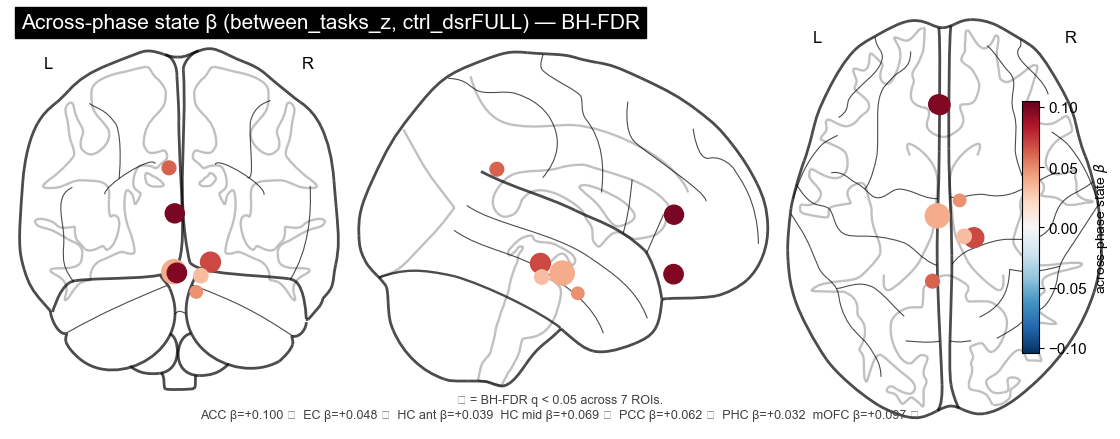

Saved -> /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_state_sustained_cv/2026-06-22_17-35-48/playground_figures/D_brain_across_phase_state_beta_FDR.pdf


In [9]:
from nilearn import plotting
import matplotlib as mpl

def plot_brain_heatmap(roi_xyz, value_col='beta_across_phase',
                        sig_col='q_fdr', sig_alpha=0.05, vmax=None,
                        title='', save_stem=None):
    """nilearn glass-brain. One dot per ROI at its mean MNI centroid.
    colour = value (RdBu_r), size ~ n_cells, edge = FDR-significant."""
    coords = roi_xyz[['MNI_x','MNI_y','MNI_z']].to_numpy()
    vals = roi_xyz[value_col].to_numpy()
    qs   = roi_xyz[sig_col].to_numpy() if sig_col in roi_xyz.columns else None
    ns   = roi_xyz['n_cells'].to_numpy()
    labels = roi_xyz['roi'].tolist()
    if vmax is None:
        vmax = float(np.nanmax(np.abs(vals))) * 1.05
    sizes = 80 + 220 * (ns - ns.min()) / max(ns.max() - ns.min(), 1)
    fig = plt.figure(figsize=(11, 4.2))
    display = plotting.plot_glass_brain(
        None, figure=fig, display_mode='ortho',
        title=title, colorbar=False, black_bg=False,
    )
    adj = np.zeros((len(coords), len(coords)))
    display.add_graph(
        adj, coords,
        node_color=plt.cm.RdBu_r((vals + vmax) / (2*vmax)),
        node_size=sizes,
        edge_threshold='100%',
    )
    cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.6])
    sm = plt.cm.ScalarMappable(
        cmap='RdBu_r', norm=mpl.colors.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'across-phase state $\beta$', fontsize=10)
    legend = '  '.join(
        f'{pretty(r)} β={v:+.3f}'
        + (' ★' if (qs is not None and np.isfinite(q) and q < sig_alpha) else '')
        for r, v, q in zip(labels, vals, qs if qs is not None else [None]*len(vals)))
    fig.text(0.5, 0.02, f'★ = BH-FDR q < {sig_alpha:g} across {len(vals)} ROIs.\n{legend}',
             ha='center', va='bottom', fontsize=9, color='0.25', wrap=True)
    if save_stem:
        fig.savefig(str(save_stem) + '.pdf', bbox_inches='tight')
        fig.savefig(str(save_stem) + '.png', dpi=300, bbox_inches='tight')
    return fig, display

fig, _ = plot_brain_heatmap(
    roi_xyz,
    title='Across-phase state β (between_tasks_z, ctrl_dsrFULL) — BH-FDR',
    save_stem=OUT_DIR / 'D_brain_across_phase_state_beta_FDR',
)
plt.show()
print(f'Saved -> {OUT_DIR}/D_brain_across_phase_state_beta_FDR.pdf')


In [10]:
# ---- quickbrain stub (works only when this notebook is run in a Python >=3.10 env) ----
def try_quickbrain():
    try:
        import quickbrain as qb
    except Exception as e:
        print(f'quickbrain unavailable: {e}')
        print('Install: pip install git+https://github.com/pni-lab/quickbrain  (needs Python >=3.10)')
        return None
    # Minimal placeholder: feed the same per-ROI dots as nilearn version.
    # See https://pni-lab.github.io/quickbrain/getting-started/ for API.
    print('quickbrain imported — build the figure here. API:', dir(qb)[:10])
    return qb

try_quickbrain()

quickbrain unavailable: No module named 'quickbrain'
Install: pip install git+https://github.com/pni-lab/quickbrain  (needs Python >=3.10)


## Next iteration ideas

- Cross-test panel: state β in `split_halves_z` AND `between_tasks_z` side-by-side.
- Overlay the sustained sig-fraction (Plot B) onto the brain dots (size = N cells, colour = frac sustained, edge = sig).
- Per-cell scatter: `min_phase_contrast` vs `mean_r` per ROI, coloured by `sustained_sig`.
- Add `dsr_fmri_informed` panel beside the state heatmap to make the joint state→DSR story visible in one figure.

## 7. PLOT E — fMRI state ROI-mean betas (hemisphere-restricted)
Mean β per subject within each ROI mask, restricted to the hemisphere where FWE-significant voxels concentrate inside that mask. FWE correction: voxel-wise within a PFC+MTL search mask. Stats and figure data come from `fMRI_state/fig_state_roi_betas_stats.json` (see `scripts/get_subj_effects_fMRI.py`). Stars on the figure reflect the descriptive within-ROI one-sample t-test against zero; FWE-corrected p-values are printed below the figure.

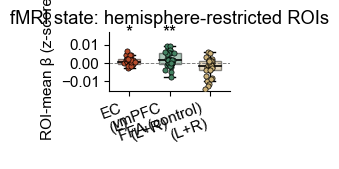

FWE correction: voxel-wise FWE within PFC+MTL mask  |  n=32

ROI-mean per-subject one-sample t-tests:
  EC                  L  nvox=895    mean=+0.00080  t=+2.16  p=0.0195  *
  vmPFC             L+R  nvox=1200   mean=+0.00182  t=+2.51  p=0.0087  **
  FFA (control)     L+R  nvox=112    mean=-0.00249  t=-2.83  p=0.9960  n.s.

FWE-significant peaks:
  rank 1: MNI=(-20,+2,-36)  peak t=5.18  cluster=1 vox  FWE p≤0.0394  inside=EC


In [11]:
# Re-plot ROI-mean betas from the saved stats JSON so the figure stays editable.
STATS = Path('/Users/xpsy1114/Documents/projects/multiple_clocks/data/final_results/fMRI_state/fig_state_roi_betas_stats.json')
with open(STATS) as f:
    stats_d = json.load(f)

pass_data = stats_d['pass2_unilateral_mask']
region_order = list(pass_data.keys())
palette = era_brewer.era_brew('Showgirl2', n=max(len(region_order), 5))

fig, ax = plt.subplots(figsize=(5/2.54, 4/2.54), constrained_layout=True)
positions = np.arange(len(region_order)) + 1
box_data = [np.asarray(pass_data[r]['values'], float) for r in region_order]
bp = ax.boxplot(box_data, positions=positions, widths=0.55,
                showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.2))
for patch, c in zip(bp['boxes'], palette):
    patch.set_facecolor(c); patch.set_alpha(0.45); patch.set_edgecolor('black')
rng = np.random.default_rng(42)
for i, (d, c) in enumerate(zip(box_data, palette)):
    jitter = 0.07 * rng.standard_normal(d.size)
    ax.scatter(positions[i] + jitter, d, s=14, color=c,
               edgecolor='black', linewidth=0.5, zorder=3)
ax.axhline(0, color='gray', ls='--', lw=0.7)
ax.set_xticks(positions)
labels = [f"{r}\n({pass_data[r]['hemisphere'] or 'L+R'})" for r in region_order]
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('ROI-mean β (z-scored)')
ax.set_title('fMRI state: hemisphere-restricted ROIs')
for sp in ('top','right'): ax.spines[sp].set_visible(False)
ymin, ymax = ax.get_ylim()
scale = ymax - ymin
star_y = ymax + scale * 0.04
for i, r in enumerate(region_order):
    s = pass_data[r]['sig']
    if s == 'n.s.':
        continue
    ax.text(positions[i], star_y, s, ha='center', va='bottom', fontsize=13)
ax.set_ylim(ymin, star_y + scale * 0.20)
plt.show()

print(f"FWE correction: {stats_d['settings']['fwe_correction_mode']}  |  n={stats_d['inputs']['n_subjects']}")
print('\nROI-mean per-subject one-sample t-tests:')
for r in region_order:
    rs = pass_data[r]
    h = rs['hemisphere'] or 'L+R'
    print(f"  {r:16s} {h:>4s}  nvox={rs['n_voxels_in_mask']:<5d}  mean={rs['mean']:+.5f}  t={rs['t']:+.2f}  p={rs['p']:.4f}  {rs['sig']}")
print('\nFWE-significant peaks:')
for pk in stats_d['fwe_peaks']:
    print(f"  rank {pk['rank']}: MNI=({pk['mni'][0]:+.0f},{pk['mni'][1]:+.0f},{pk['mni'][2]:+.0f})"
          f"  peak t={pk['peak_tstat']:.2f}  cluster={pk['cluster_size_voxels']} vox"
          f"  FWE p≤{pk['fwe_p_min']:.4f}  inside={pk['inside_roi'] or '-'}")


## 8. PLOT F — Sustained-state v5 publication figures

The figures below are the canonical publication-quality outputs from `scripts/encoding_state_sustained_cv.py` (sum-coded GLM, OLS, `min_phase_contrast` perm-tested as the sustained gate; `r_state` and `r_interaction` encoding-correlation tests as descriptors). All figures are sized for A4 print; captions are copied from `captions.md`.

**Headline statistics (omnibus across ROIs + EC vs. rest):**
- sustained: omnibus χ² p = 0.183, EC vs rest p = 0.073 (borderline)
- r_state:    omnibus χ² p = 0.561, EC vs rest p = 0.149
- r_interaction: omnibus χ² p = **0.012**, EC vs rest p = 0.773
- phasic-only:   omnibus χ² p = 0.057, EC vs rest p = 0.649

Read: sustained encoding above chance in all 7 ROIs, but cross-ROI heterogeneity not significant. Phasic encoding (r_interaction) IS heterogeneous — driven by PCC and HC_mid.

In [ ]:
# Load v5 publication outputs
import json
from IPython.display import Image, Markdown, display

sustained_v5 = pd.read_csv(SUSTAINED_RUN / 'state_sustained_cv_results.csv')
roi_summary  = pd.read_csv(SUSTAINED_RUN / 'state_sustained_cv_roi_summary.csv')
with open(PUB_FIGS / 'roi_inference.json') as f:
    roi_inference = json.load(f)

print(f'v5 sustained: {len(sustained_v5)} cells, '
      f"{sustained_v5['sig_sustained'].sum()} sustained, "
      f"{((sustained_v5['sig_r_state']|sustained_v5['sig_r_interaction']) & ~sustained_v5['sig_sustained']).sum()} phasic-only")

display(Markdown('**ROI summary (sustained / phasic-only fractions):**'))
display(roi_summary[['roi','n_cells','n_sustained','frac_sustained','binom_p_sustained',
                      'n_phasic_only','frac_phasic_only','binom_p_phasic_only',
                      'overrep_state','overrep_state_p_binom']]
        .round(4))

### Main figure — per-ROI fractions overview

Panel (a) sustained, (b) state-encoding generalises, (c) phasic-only (/// hatched), (d) **stacked composition** per ROI (sustained + phasic-only + neither sum to 1.0). Bars in era_brewer ROI colours. Stars = binomial p vs 5 %. 

In [ ]:
display(Image(filename=str(PUB_FIGS / '08_roi_fractions_overview.png'), width=700))

### Per-phase contrast by category

Boxes coloured by phase (pastel pink → bordeaux). Black solid = median, black dotted = mean. Sustained cells show contrast > 0 in all 3 phases; phasic-only cells show the collapse-in-one-phase pattern.

In [ ]:
display(Image(filename=str(PUB_FIGS / '07_per_phase_by_category.png'), width=700))

### Preferred-state distribution per ROI (sustained cells)

Stacked bars in state colours. Stars above each bar = binomial p of the most-overrepresented state vs. uniform 1/4. ACC → D (p = .009), HC_mid → D (p = .038).

In [ ]:
display(Image(filename=str(PUB_FIGS / '10_pref_state_stacked.png'), width=560))

### Per-ROI distributions (5 = min_phase_contrast, 6 = r_state, 6b = r_interaction)

Light grey = all cells in the ROI; ROI-coloured = perm-sig cells (α=.05). Black line = mean of the distribution.

In [ ]:
display(Image(filename=str(PUB_FIGS / '05_dist_min_phase_contrast_per_roi.png'), width=720))
display(Image(filename=str(PUB_FIGS / '06_dist_r_state_per_roi.png'), width=720))
display(Image(filename=str(PUB_FIGS / '06b_dist_r_interaction_per_roi.png'), width=720))

### Permutation null sanity check

Each row = one example cell across the significance spectrum. Grey = circular-shift null; dark green = observed empirical value. p reported under each axis.

In [ ]:
display(Image(filename=str(PUB_FIGS / '03_perm_nulls_examples.png'), width=560))

### Cross-ROI inference (omnibus χ² + EC vs rest Fisher exact)

From `roi_inference.json`. Omnibus tests whether perm-sig fractions are homogeneous across the 7 ROIs (one test per outcome). The EC-vs-rest contrast is the planned a-priori test.

In [ ]:
rows = []
for outcome, vals in roi_inference.items():
    rows.append({'outcome': outcome,
                 'omnibus_chi2_p': vals['chi2_omnibus_p'],
                 'EC_vs_rest_p (Fisher)': vals['fisher_EC_vs_rest_p']})
pd.DataFrame(rows).round(4)

### Example-cell gallery

Per-category folders in `diagnostic_figures/example_gallery/` with up to 25 PDFs per category (sustained / phasic_only / non_state). EC cells are prioritised in the sustained gallery (top 5 EC cells included before the round-robin fill). Each PDF: mean polar + per-config polars, per-cell rescaling, large A/B/C/D state letters.

In [ ]:
gallery = PUB_FIGS / 'example_gallery'
if gallery.exists():
    for cat in ['sustained', 'phasic_only', 'non_state']:
        files = sorted((gallery / cat).glob('*.pdf'))
        ec_count = sum('_EC_' in f.name for f in files)
        print(f'{cat:14s}: {len(files):>2d} cells   (EC: {ec_count})')
else:
    print('Gallery not built yet — run:\n'
          '    python scripts/encoding_state_sustained_cv.py --gallery --gallery-n 25')

### Population-shift Wilcoxon test (per-cell perm-p vs. uniform)

Most powerful of the three ROI-level inference flavours. Under H₀, per-cell perm-p is Uniform[0, 1] regardless of any bias in the empirical statistic — so the median = 0.5 is a clean reference (no special treatment for the downward bias of `min_phase_contrast`). Multiple comparisons across the 7 ROIs are corrected with **BH-FDR (primary)**; Bonferroni-FWE shown alongside for reference. The FDR-corrected stars are drawn on figs 05/06/06b next to the ROI names and as solid borders on the fig 11 heatmap; dotted borders on fig 11 = raw p < .05 that did NOT survive FDR.

In [ ]:
rows = []
def stars(q):
    if not pd.notna(q): return ''
    return '***' if q < .001 else '**' if q < .01 else '*' if q < .05 else 'ns'
for _, row in roi_summary.iterrows():
    rec = {'roi': row['roi'], 'n_cells': int(row['n_cells'])}
    for prefix in ['min_phase', 'r_state', 'r_interaction']:
        rec[f'{prefix}__raw_p'] = row[f'wilcoxon_p_{prefix}']
        rec[f'{prefix}__FDR_q'] = row[f'q_wilcoxon_{prefix}']
        rec[f'{prefix}__FDR_sig'] = stars(row[f'q_wilcoxon_{prefix}'])
        rec[f'{prefix}__FWE_p']  = row[f'fwe_wilcoxon_{prefix}']
    rows.append(rec)
display(pd.DataFrame(rows).round(5))

### Effect-size heatmap (fig 11)

ROI × statistic heatmap in the style of `encoding_publication_panels.py`. **Colour = per-ROI one-sample t-statistic of the empirical value vs 0** (an effect-size measure, not a p-value).

Two side-by-side panels because the three stats live on different scales:
- **Left** (`r_state`, `r_interaction`, RdBu_r): both are correlations whose null mean is 0, so the t-vs-0 is interpretable as an effect size.
- **Right** (`min_phase_contrast`, PuOr_r): the perm null is biased downward (≈ −0.846 σ_cell for min-of-3 noise), so its t-vs-0 is mechanically negative — only the cross-ROI ordering is meaningful. The separate colourmap signals the different scale.

**Borders use the bias-free Wilcoxon perm-p shift test**: solid black = BH-FDR significant (q < .05 across 7 ROIs); dotted black = raw Wilcoxon p < .05 but does NOT survive FDR; no border = non-significant.

In [ ]:
display(Image(filename=str(PUB_FIGS / '11_effect_size_heatmap.png'), width=520))

### Fig 8b — fractions grouped by ROI

Same data as fig 8 but bars grouped per ROI: each ROI shows three bars side by side — all-state (light), sustained (solid), phasic-only (/// hatched). Easier to read off the within-ROI composition than the across-ROI strip layout in fig 8.

In [ ]:
display(Image(filename=str(PUB_FIGS / '08b_roi_fractions_grouped.png'), width=620))